In [ ]:
!pip install scanpy anndata scikit-misc


import os
import torch
import pandas as pd
import scanpy as sc
# @title
# Create a data directory if it doesn't exist
!mkdir -p data

# Download the dataset from Google Drive into the data directory
# The provided link is a folder ID, gdown can download its contents.
# Change this to a specific file ID if you want to download a single file.
folder_id = '1U06il0AEEEryRXUVXESUEBWDY_0fH-s9'
!gdown --id {folder_id} --folder --output data

import os
import scipy
import anndata
import sklearn
import torch
import random
import numpy as np
import scanpy as sc
import pandas as pd
from typing import Optional
import scipy.sparse as sp
from torch.backends import cudnn
from scipy.sparse import coo_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import kneighbors_graph



def pca(adata, use_reps=None, n_comps=10):

    """Dimension reduction with PCA algorithm"""

    from sklearn.decomposition import PCA
    from scipy.sparse.csc import csc_matrix
    from scipy.sparse.csr import csr_matrix
    pca = PCA(n_components=n_comps)
    if use_reps is not None:
       feat_pca = pca.fit_transform(adata.obsm[use_reps])
    else:
       if isinstance(adata.X, csc_matrix) or isinstance(adata.X, csr_matrix):
          feat_pca = pca.fit_transform(adata.X.toarray())
       else:
          feat_pca = pca.fit_transform(adata.X)

    return feat_pca

def clr_normalize_each_cell(adata, inplace=True):

    """Normalize count vector for each cell, i.e. for each row of .X"""

    import numpy as np
    import scipy

    def seurat_clr(x):
        # TODO: support sparseness
        s = np.sum(np.log1p(x[x > 0]))
        exp = np.exp(s / len(x))
        return np.log1p(x / exp)

    if not inplace:
        adata = adata.copy()

    # apply to dense or sparse matrix, along axis. returns dense matrix
    adata.X = np.apply_along_axis(
        seurat_clr, 1, (adata.X.toarray() if scipy.sparse.issparse(adata.X) else np.array(adata.X))
    )
    return adata


def lsi(
        adata: anndata.AnnData, n_components: int = 20,
        use_highly_variable: Optional[bool] = None, **kwargs
       ) -> None:
    r"""
    LSI analysis (following the Seurat v3 approach)
    """
    if use_highly_variable is None:
        use_highly_variable = "highly_variable" in adata.var
    adata_use = adata[:, adata.var["highly_variable"]] if use_highly_variable else adata
    X = tfidf(adata_use.X)
    #X = adata_use.X
    X_norm = sklearn.preprocessing.Normalizer(norm="l1").fit_transform(X)
    X_norm = np.log1p(X_norm * 1e4)
    X_lsi = sklearn.utils.extmath.randomized_svd(X_norm, n_components, **kwargs)[0]
    X_lsi -= X_lsi.mean(axis=1, keepdims=True)
    X_lsi /= X_lsi.std(axis=1, ddof=1, keepdims=True)
    #adata.obsm["X_lsi"] = X_lsi
    adata.obsm["X_lsi"] = X_lsi[:,1:]

def tfidf(X):
    r"""
    TF-IDF normalization (following the Seurat v3 approach)
    """
    idf = X.shape[0] / X.sum(axis=0)
    if scipy.sparse.issparse(X):
        tf = X.multiply(1 / X.sum(axis=1))
        return tf.multiply(idf)
    else:
        tf = X / X.sum(axis=1, keepdims=True)
        return tf * idf

def fix_seed(seed):
    #seed = 2023
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


! ls



# Path for Human Lymph Node 10x Visium
rna_path = 'data/10x_human_lymph_node_D1/adata_RNA.h5ad'
pro_path = 'data/10x_human_lymph_node_D1/adata_ADT.h5ad'
annotation_path = 'data/10x_human_lymph_node_D1/annotation.csv'

adata_omics1 = sc.read_h5ad(rna_path)
adata_omics2 = sc.read_h5ad(pro_path)
anno_df = pd.read_csv(annotation_path, index_col='Unnamed: 0')

print("Data loaded successfully from the separate data folder!")

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

print("variable named unique")


# 2. Add the 'manual-anno' column to the 'obs' dataframe of both AnnData objects
# Pandas will automatically align the indices (Barcodes)
adata_omics1.obs['ground_truth'] = anno_df['manual-anno']
adata_omics2.obs['ground_truth'] = anno_df['manual-anno']

print("Ground truth added successfully!")

print(adata_omics1)
print(adata_omics2)


# RNA
sc.pp.filter_genes(adata_omics1, min_cells=10)
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)

adata_omics1_high =  adata_omics1[:, adata_omics1.var['highly_variable']]
adata_omics1.obsm['feat'] = pca(adata_omics1_high, n_comps=adata_omics2.n_vars-1)

# Protein
adata_omics2 = clr_normalize_each_cell(adata_omics2)
sc.pp.scale(adata_omics2)
adata_omics2.obsm['feat'] = pca(adata_omics2, n_comps=adata_omics2.n_vars-1)



from sklearn.cluster import KMeans

# Concatenate feature matrices
joint_feat = np.concatenate((adata_omics1.obsm['feat'], adata_omics2.obsm['feat']), axis=1)

# Store joint_feat in adata_omics1.obsm for neighbor graph computation
adata_omics1.obsm['joint_feat'] = joint_feat

# Perform KMeans clustering
k_means_model = KMeans(n_clusters=7, random_state=0, n_init=10) # Using 8 clusters as an initial guess
clusters = k_means_model.fit_predict(joint_feat)

# Add cluster assignments to both AnnData objects
adata_omics1.obs['kmeans_clusters'] = clusters.astype(str)
adata_omics2.obs['kmeans_clusters'] = clusters.astype(str)

# print("KMeans clustering performed successfully!")
# print("Cluster distribution for omics1:")
# display(adata_omics1.obs['kmeans_clusters'].value_counts())
# print("Cluster distribution for omics2:")
# display(adata_omics2.obs['kmeans_clusters'].value_counts())

from sklearn.cluster import KMeans

# Concatenate feature matrices
joint_feat = np.concatenate((adata_omics1.obsm['feat'], adata_omics2.obsm['feat']), axis=1)

# Store joint_feat in adata_omics1.obsm for neighbor graph computation
adata_omics1.obsm['joint_feat'] = joint_feat

# Perform KMeans clustering
k_means_model = KMeans(n_clusters=11, random_state=0, n_init=10) # Using 8 clusters as an initial guess
clusters = k_means_model.fit_predict(joint_feat)

# Add cluster assignments to both AnnData objects
adata_omics1.obs['kmeans_clusters'] = clusters.astype(str)
adata_omics2.obs['kmeans_clusters'] = clusters.astype(str)

print("KMeans clustering performed successfully!")
print("Cluster distribution for omics1:")
display(adata_omics1.obs['kmeans_clusters'].value_counts())
print("Cluster distribution for omics2:")
display(adata_omics2.obs['kmeans_clusters'].value_counts())

adata=adata_omics1.copy()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    v_measure_score,
    silhouette_score
)

y_true = adata.obs['ground_truth'].astype(str)
y_pred = adata.obs['kmeans_clusters'].astype(str)

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
ami = adjusted_mutual_info_score(y_true, y_pred)
homogeneity = homogeneity_score(y_true, y_pred)
v_measure = v_measure_score(y_true, y_pred)

sil_score = silhouette_score(
    joint_feat,
    adata.obs['kmeans_clusters'].astype(int)
)

print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"AMI: {ami:.4f}")
print(f"Homogeneity: {homogeneity:.4f}")
print(f"V-measure: {v_measure:.4f}")
print(f"Silhouette: {sil_score:.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 900.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_1752/3215566845.py:41: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.csc import csc_matrix
/tmp/ipykernel_1752/3215566845.py:42: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy

KMeans clustering performed successfully!
Cluster distribution for omics1:


,count
kmeans_clusters,
7,671
1,519
4,444
10,379
2,314
5,310
3,233
0,170
8,137


Cluster distribution for omics2:


,count
kmeans_clusters,
7,671
1,519
4,444
10,379
2,314
5,310
3,233
0,170
8,137


ARI: 0.1897
NMI: 0.3335
AMI: 0.3281
Homogeneity: 0.3880
V-measure: 0.3335
Silhouette: 0.0238


In [ ]:
print(adata_omics1.obs['ground_truth'].value_counts())

ground_truth
Medullary Chords     1451
Medullary Sinus       655
Paracortex            484
Adipose Tlssue        295
Cortex                133
Capsule               133
Marginal Sinus        118
Endothelial            33
B cell Follicle        32
Connective Tissue      15
Exclude                10
Name: count, dtype: int64


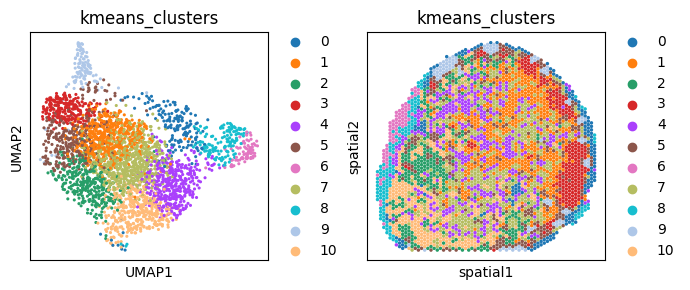

In [ ]:


# visualization
import matplotlib.pyplot as plt
fig, ax_list = plt.subplots(1, 2, figsize=(7, 3))


# Use the 'joint_feat' from obsm for computing neighbors
sc.pp.neighbors(adata, use_rep='joint_feat', n_neighbors=10)
sc.tl.umap(adata)

sc.pl.umap(adata, color='kmeans_clusters', ax=ax_list[0], title='kmeans_clusters', s=20, show=False)
sc.pl.embedding(adata, basis='spatial', color='kmeans_clusters', ax=ax_list[1], title='kmeans_clusters', s=25, show=False)

plt.tight_layout(w_pad=0.3)
plt.show()

### UMAP and Spatial Plots by Ground Truth

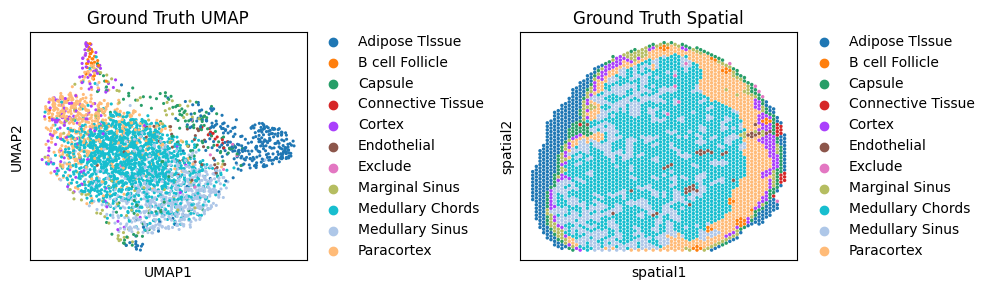

In [ ]:
fig_gt, ax_list_gt = plt.subplots(1, 2, figsize=(10, 3))

sc.pl.umap(adata, color='ground_truth', ax=ax_list_gt[0], title='Ground Truth UMAP', s=20, show=False)
sc.pl.embedding(adata, basis='spatial', color='ground_truth', ax=ax_list_gt[1], title='Ground Truth Spatial', s=25, show=False)

plt.tight_layout(w_pad=0.8)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# Define the range for n_clusters
min_clusters = 5
max_clusters = 15

# Initialize lists to store metrics
cluster_range = []
aris = []
mis = []
amis = []
homogeneities = []
v_measures = []
silhouettes = []

for n_clusters in range(min_clusters, max_clusters + 1):
    print(f"\n--- Running KMeans with {n_clusters} clusters ---")
    # Perform KMeans clustering
    k_means_model = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    clusters = k_means_model.fit_predict(joint_feat)

    # Add cluster assignments to adata
    adata.obs['kmeans_clusters_iter'] = clusters.astype(str)

    # Calculate metrics
    y_true = adata.obs['ground_truth'].astype(str)
    y_pred = adata.obs['kmeans_clusters_iter'].astype(str)

    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    homogeneity = homogeneity_score(y_true, y_pred)
    v_measure = v_measure_score(y_true, y_pred)

    # Silhouette score requires integer clusters
    sil_score = silhouette_score(joint_feat, adata.obs['kmeans_clusters_iter'].astype(int))

    # Store results
    cluster_range.append(n_clusters)
    aris.append(ari)
    mis.append(nmi)
    amis.append(ami)
    homogeneities.append(homogeneity)
    v_measures.append(v_measure)
    silhouettes.append(sil_score)
    print(f"Cluster: {n_clusters}")
    print(f"ARI: {ari:.4f}")
    print(f"NMI: {nmi:.4f}")
    print(f"AMI: {ami:.4f}")
    print(f"Homogeneity: {homogeneity:.4f}")
    print(f"V-measure: {v_measure:.4f}")
    print(f"Silhouette: {sil_score:.4f}")

# Create a DataFrame to display all results
metrics_df = pd.DataFrame({
    'N_Clusters': cluster_range,
    'ARI': aris,
    'NMI': mis,
    'AMI': amis,
    'Homogeneity': homogeneities,
    'V_Measure': v_measures,
    'Silhouette': silhouettes
})

display(metrics_df)



--- Running KMeans with 5 clusters ---
Cluster: 5
ARI: 0.2840
NMI: 0.3399
AMI: 0.3371
Homogeneity: 0.2983
V-measure: 0.3399
Silhouette: 0.0779

--- Running KMeans with 6 clusters ---
Cluster: 6
ARI: 0.2380
NMI: 0.3054
AMI: 0.3021
Homogeneity: 0.2937
V-measure: 0.3054
Silhouette: 0.0565

--- Running KMeans with 7 clusters ---
Cluster: 7
ARI: 0.2757
NMI: 0.3603
AMI: 0.3567
Homogeneity: 0.3604
V-measure: 0.3603
Silhouette: 0.0537

--- Running KMeans with 8 clusters ---
Cluster: 8
ARI: 0.2301
NMI: 0.3357
AMI: 0.3316
Homogeneity: 0.3536
V-measure: 0.3357
Silhouette: 0.0404

--- Running KMeans with 9 clusters ---
Cluster: 9
ARI: 0.2254
NMI: 0.3581
AMI: 0.3537
Homogeneity: 0.3878
V-measure: 0.3581
Silhouette: 0.0371

--- Running KMeans with 10 clusters ---
Cluster: 10
ARI: 0.2049
NMI: 0.3400
AMI: 0.3350
Homogeneity: 0.3834
V-measure: 0.3400
Silhouette: 0.0280

--- Running KMeans with 11 clusters ---
Cluster: 11
ARI: 0.1897
NMI: 0.3335
AMI: 0.3281
Homogeneity: 0.3880
V-measure: 0.3335
Silhoue

,N_Clusters,ARI,NMI,AMI,Homogeneity,V_Measure,Silhouette
0,5,0.283976,0.339862,0.337062,0.298266,0.339862,0.077944
1,6,0.237960,0.305417,0.302055,0.293725,0.305417,0.056493
2,7,0.275748,0.360303,0.356725,0.360408,0.360303,0.053670
3,8,0.230085,0.335716,0.331587,0.353636,0.335716,0.040426
4,9,0.225366,0.358131,0.353695,0.387761,0.358131,0.037146
5,10,0.204900,0.339970,0.335028,0.383352,0.339970,0.027966
6,11,0.189672,0.333528,0.328138,0.387972,0.333528,0.023819
7,12,0.153086,0.321204,0.315351,0.386673,0.321204,0.026171
8,13,0.165783,0.331156,0.324930,0.400415,0.331156,0.020998
9,14,0.159321,0.324740,0.318030,0.399204,0.324740,0.020476
